> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
%pip install -q coptpy matplotlib


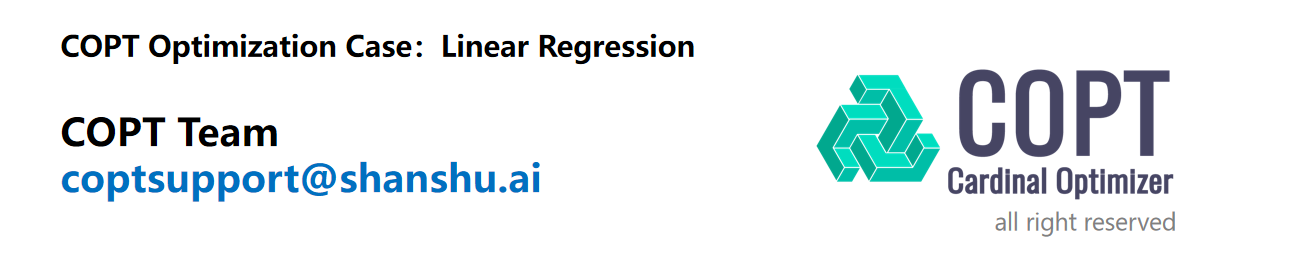

# Linear Regression Code Implementation
## Steps for Solving Linear Regression Using COPT Modeling

1. **Import the COPT-Python interface library** `coptpy`

2. Add/import model **data**

3. Create **Solving Environment** and Solving **Model**

4. Build the model and add the **three elements of the model** in sequence
   - **Decision Variables**
   - **Objective Function**
   - **Constraints**

5. **Solve**

6. View and analyze solution **results**

### Import COPT-Python API

In [1]:
from coptpy import *

### Data

`point_data` is the 19 known data points, where the key of `point_data` is the point label, and the value corresponding to the key is the point data $(x,y)$.

In [3]:
# point: [x, y]
point_data = {
    0: [0.0, 1.0],
    1: [0.5, 0.9],
    2: [1.0, 0.7],
    3: [1.5, 1.5],
    4: [1.9, 2.0],
    5: [2.5, 2.4],
    6: [3.0, 3.2],
    7: [3.5, 2.0],
    8: [4.0, 2.7],
    9: [4.5, 3.5],
    10: [5.0, 1.0],
    11: [5.5, 4.0],
    12: [6.0, 3.6],
    13: [6.6, 2.7],
    14: [7.0, 5.7],
    15: [7.6, 4.6],
    16: [8.5, 6.0],
    17: [9.0, 6.8],
    18: [10.0, 7.3],
}

We hope to take out the $x$ and $y$ of the point in `point_data` respectively to facilitate drawing and subsequent processing.

Here we use the `multidict(data)` method of COPT. `multidict(data)` can split the input Python dictionary object into multiple dictionary objects and return them. Specifically, `multidict(point_data)` will return the key of `point_data`, the dictionary corresponding to the key `x`, and the dictionary corresponding to the key `y`.

In [5]:
points, x, y = multidict(point_data)

print('points:', points)
print('\nx:', x)
print('\ny:', y)

points: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

x: {0: 0.0, 1: 0.5, 2: 1.0, 3: 1.5, 4: 1.9, 5: 2.5, 6: 3.0, 7: 3.5, 8: 4.0, 9: 4.5, 10: 5.0, 11: 5.5, 12: 6.0, 13: 6.6, 14: 7.0, 15: 7.6, 16: 8.5, 17: 9.0, 18: 10.0}

y: {0: 1.0, 1: 0.9, 2: 0.7, 3: 1.5, 4: 2.0, 5: 2.4, 6: 3.2, 7: 2.0, 8: 2.7, 9: 3.5, 10: 1.0, 11: 4.0, 12: 3.6, 13: 2.7, 14: 5.7, 15: 4.6, 16: 6.0, 17: 6.8, 18: 7.3}


We draw a graph to observe the distribution of points $(x,y)$ and think that the linear regression model is more appropriate.

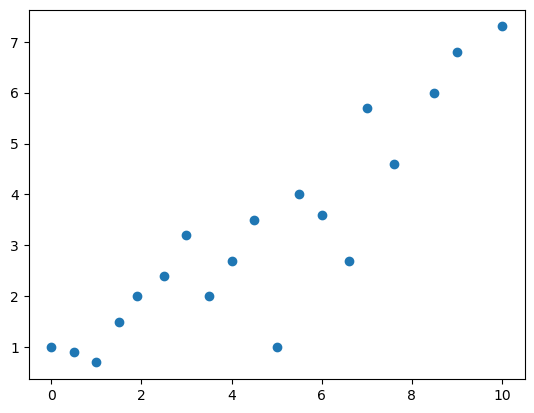

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(x.values(), y.values(), marker='o')
plt.show()

### Question one

#### Create model

Create a model `model_1` named `linear_regression_q1`.

In [9]:
env = Envr()
model_1 = env.createModel("linear_regression_q1")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



#### Add decision variables

Add decision variables $k,b,\{\epsilon_{i}\}_{i=1}^{n},\{t_{i}\}_{i=1}^{n}$.

What should be noted here is that the default parameters of `Model.addVar()` and `Model.addVars()` are `lb=0.0` and `ub=COPT.INFINITY`, but here $k,b,\{\epsilon_{i }\}_{i=1}^{n},\{t_{i}\}_{i=1}^{n}$ are all unbounded.

And for $i=1,...,n$, we have
$$
\begin{cases}
\epsilon_{i} \leq t_{i} \\
\epsilon_{i} \geq -t_{i}
\end{cases}
\ \Rightarrow\ t_{i} \geq 0
$$
So here `t` can also use the default `lb=0.0`.

In [11]:
k = model_1.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="k")
b = model_1.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="b")
e = model_1.addVars(points, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="e")
t = model_1.addVars(points, nameprefix="t")

#### Add constraints

Add constraints using `Model.addConstrs()`
$$
\begin{aligned}
& y_{i} = kx_{i} + b + \epsilon_{i}, &i = 1,...,n \\
& \epsilon_{i} \leq t_{i}, &i = 1,...,n \\
& \epsilon_{i} \geq -t_{i}, &i = 1,...,n
\end{aligned}
$$

In [13]:
model_1.addConstrs(k*x[i] + b + e[i] == y[i] for i in points)
model_1.addConstrs(e[i] <= t[i] for i in points)
model_1.addConstrs(e[i] >= -t[i] for i in points)

#### Set the objective function and solve it

The objective function is
$$
\min_{k,b\in\mathbb{R}}\ \sum_{i=1}^{n} t_{i}
$$
Use `tupledict.sum()` to add an objective function for summation.

In [15]:
model_1.setObjective(t.sum(), sense=COPT.MINIMIZE)
model_1.solve()

Model fingerprint: 969272f4

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an LP problem

The original problem has:
    57 rows, 40 columns and 132 non-zero elements
The presolved problem has:
    38 rows, 21 columns and 112 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [3e-01,2e+00]
    Range of rhs coefficients:       [1e+00,6e+00]
    Range of bound coefficients:     [0e+00,0e+00]
    Range of cost coefficients:      [5e-01,2e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    0.0000000000e+00           19           0       0.04s
Dual            21    1.1466557094e+01            0           0       0.05s
Postsolving
Dual            21    1.1466250000e+01            0           0 

#### View Results

The regression result is $y = 0.6375x + 0.5813$, and we draw the straight line obtained by linear regression.

y = 0.6375x + (0.5813)


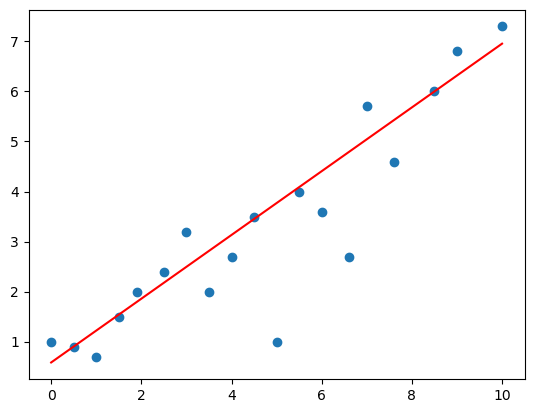

In [17]:
if model_1.status == COPT.OPTIMAL:
    print('y = {0:.4f}x + ({1:.4f})'.format(k.x, b.x))
    
    x1, x2 = min(x.values()), max(x.values())
    y1 = k.x*x1 + b.x
    y2 = k.x*x2 + b.x
    plt.scatter(x.values(), y.values(), marker='o')
    plt.plot([x1,x2], [y1,y2], color='r')
    plt.show()

### Question 2

#### Create model

Create a model `model_2` named `linear_regression_q2`.

In [19]:
model_2 = env.createModel("linear_regression_q2")

#### Add decision variables

Add decision variables $k,b,\{\epsilon_{i}\}_{i=1}^{n},z$.

Here for $i=1,...,n$, we have
$$
\begin{cases}
\epsilon_{i} \leq z \\
\epsilon_{i} \geq -z
\end{cases}
\ \Rightarrow\ z \geq 0
$$
So here `z` can also use the default `lb=0.0` of `Model.addVar()`.

In [21]:
k = model_2.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="k")
b = model_2.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="b")
e = model_2.addVars(points, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="e")
z = model_2.addVar(name="z")

#### Add constraints

Add constraints using `Model.addConstrs()`
$$
\begin{aligned}
& y_{i} = kx_{i} + b + \epsilon_{i}, &i = 1,...,n \\
& \epsilon_{i} \leq z, &i = 1,...,n \\
& \epsilon_{i} \geq -z, &i = 1,...,n
\end{aligned}
$$

In [23]:
model_2.addConstrs(k*x[i] + b + e[i] == y[i] for i in points)
model_2.addConstrs(z >= e[i] for i in points)
model_2.addConstrs(z >= -e[i] for i in points)

#### Set the objective function and solve it

The objective function is
$$
\min_{k,b\in\mathbb{R}}\ z
$$

In [25]:
model_2.setObjective(z, sense=COPT.MINIMIZE)
model_2.solve()

Model fingerprint: f4f32f6f

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an LP problem

The original problem has:
    57 rows, 22 columns and 132 non-zero elements
The presolved problem has:
    38 rows, 3 columns and 112 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [3e-01,3e+00]
    Range of rhs coefficients:       [1e+00,7e+00]
    Range of bound coefficients:     [0e+00,0e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    0.0000000000e+00           19           0       0.02s
Dual             5    1.7250231928e+00            0           0       0.02s
Postsolving
Dual             5    1.7250000000e+00            0           0  

#### View Results

The regression result is $y = 0.6250x - 0.4000$, and we draw the straight line obtained by linear regression.

y = 0.6250x + (-0.4000)


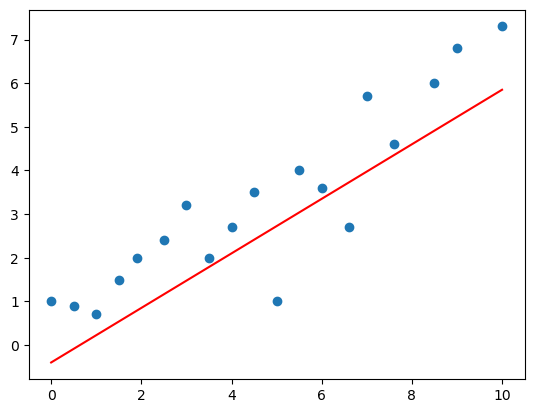

In [27]:
if model_2.status == COPT.OPTIMAL:
    print('y = {0:.4f}x + ({1:.4f})'.format(k.x, b.x))
    
    x1, x2 = min(x.values()), max(x.values())
    y1 = k.x*x1 + b.x
    y2 = k.x*x2 + b.x
    plt.scatter(x.values(), y.values(), marker='o')
    plt.plot([x1,x2], [y1,y2], color='r')
    plt.show()